## Montar Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
path = '/content/drive/MyDrive/Meli_Case'

In [3]:
import sys
sys.path.append(path)

## Imports

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
from scipy.stats import ks_2samp
import shap
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score, classification_report

## Funções

In [6]:
from functions import plot_roc_curves, encontrar_threshold_max_lucro, calculate_profit, metricas_fraude, analisar_metricas_por_decil

## Base

In [7]:
base = pd.read_excel(f"{path}/fraud_dataset.xlsx")
base = base.rename(columns={col: f"var_{col}" for col in base.columns if len(col) == 1 and col.isalpha()})

In [8]:
variaveis = ["var_Q", "var_R", "var_S", 'Monto']

for col in variaveis:
    base[col] = base[col].apply(lambda x: np.nan if isinstance(x, datetime) else x)

    base[col] = base[col].astype(str).str.replace(",", "").str.replace(" ", "").replace("None", np.nan)
    base[col] = pd.to_numeric(base[col], errors='coerce')

In [9]:
for col in ["var_C", "var_F", "var_G"]:
    base[f"{col}_log"] = np.log1p(base[col])

In [10]:
def mapear_pais(pais):
    if pais in ['BR', 'AR', 'MX']:
        return pais
    elif pais in ['ES', 'US', 'UY']:
        return 'ES_US_UY'
    else:
        return 'OUTROS'

base['pais_agg'] = base['var_J'].apply(mapear_pais)

In [11]:
pais_agg_dummies = pd.get_dummies(base['pais_agg'], prefix='pais_agg')
pais_agg_dummies = pais_agg_dummies.astype(int)

In [12]:
base = pd.concat([base, pais_agg_dummies], axis=1)
base

,var_A,var_B,var_C,var_D,var_E,var_F,var_G,var_H,var_I,var_J,...,Fraude,var_C_log,var_F_log,var_G_log,pais_agg,pais_agg_AR,pais_agg_BR,pais_agg_ES_US_UY,pais_agg_MX,pais_agg_OUTROS
0,0,10,50257.0,0,0,0.0,0.0,0,0,UY,...,1,10.824925,0.000000,0.0,ES_US_UY,0,0,1,0,0
1,0,10,29014.0,0,0,0.0,0.0,0,0,UY,...,1,10.275568,0.000000,0.0,ES_US_UY,0,0,1,0,0
2,0,7,92.0,0,1,0.0,0.0,0,1,UY,...,1,4.532599,0.000000,0.0,ES_US_UY,0,0,1,0,0
3,9,16,50269.0,0,0,0.0,0.0,0,0,UY,...,1,10.825164,0.000000,0.0,ES_US_UY,0,0,1,0,0
4,0,8,8180.0,0,0,0.0,0.0,0,0,UY,...,1,9.009570,0.000000,0.0,ES_US_UY,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16875,0,3,63302.0,0,1,0.5,0.0,0,0,BR,...,1,11.055688,0.405465,0.0,BR,0,1,0,0,0
16876,0,12,825.0,0,0,0.0,0.0,0,0,BR,...,1,6.716595,0.000000,0.0,BR,0,1,0,0,0
16877,1,3,81067.0,0,0,0.0,0.0,0,0,BR,...,1,11.303044,0.000000,0.0,BR,0,1,0,0,0
16878,0,9,398372.0,0,0,0.0,0.0,0,0,BR,...,1,12.895144,0.000000,0.0,BR,0,1,0,0,0


In [13]:
base['var_K_100'] = (base['var_K'] * 100).round()

In [14]:
drop_col = ['var_C', 'var_F', 'var_G', 'var_J', 'pais_agg', 'var_K']
base = base.drop(columns=drop_col, errors='ignore')
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16880 entries, 0 to 16879
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   var_A              16880 non-null  int64  
 1   var_B              16880 non-null  int64  
 2   var_D              16880 non-null  int64  
 3   var_E              16880 non-null  int64  
 4   var_H              16880 non-null  int64  
 5   var_I              16880 non-null  int64  
 6   var_L              16880 non-null  int64  
 7   var_M              16880 non-null  int64  
 8   var_N              16880 non-null  int64  
 9   var_O              16880 non-null  int64  
 10  var_P              16880 non-null  int64  
 11  var_Q              16863 non-null  float64
 12  var_R              16877 non-null  float64
 13  var_S              15575 non-null  float64
 14  Monto              16413 non-null  float64
 15  Fraude             16880 non-null  int64  
 16  var_C_log          136

In [15]:
df = base[base['Monto'].notna()]

## Treino, Teste e Validação

In [16]:
rf_fs = ['var_S',
 'Monto',
 'var_C_log',
 'var_B',
 'pais_agg_ES_US_UY',
 'var_K_100',
 'var_P',
 'var_M',
 'var_L',
 'var_A',
 'var_E',
 'pais_agg_MX',
 'var_F_log',
 'pais_agg_AR',
 'pais_agg_BR',
 'var_Q',
 'var_D']

In [17]:
X = df[rf_fs]
y = df["Fraude"]

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=13)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=13)

In [19]:
X_train.shape, X_test.shape, X_val.shape

((11489, 17), (2462, 17), (2462, 17))

## Melhores Hiperparâmetros

In [20]:
best = {'colsample_bytree': np.float64(0.9536957201740883),
 'gamma': np.float64(1.0416424955881598),
 'learning_rate': np.float64(0.047958206007245714),
 'max_depth': np.float64(9.0),
 'min_child_weight': np.float64(9.0),
 'n_estimators': np.float64(290.0),
 'reg_alpha': np.float64(3.855225280461912),
 'reg_lambda': np.float64(0.6684995061329557),
 'subsample': np.float64(0.8285019837004117)}

## Modelagem

In [21]:
final_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=13,
    n_jobs=-1,
    max_depth=int(best['max_depth']),
    learning_rate=best['learning_rate'],
    n_estimators=int(best['n_estimators']),
    gamma=best['gamma'],
    min_child_weight=int(best['min_child_weight']),
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda']
)

final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9536957201740883, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=1.0416424955881598, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.047958206007245714,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=290, n_jobs=-1,
              num_parallel_tree=None, random_state=13, ...)

In [22]:
y_probs_test = final_model.predict_proba(X_test)[:, 1]
y_probs_val = final_model.predict_proba(X_val)[:, 1]

## Avaliação do Modelo

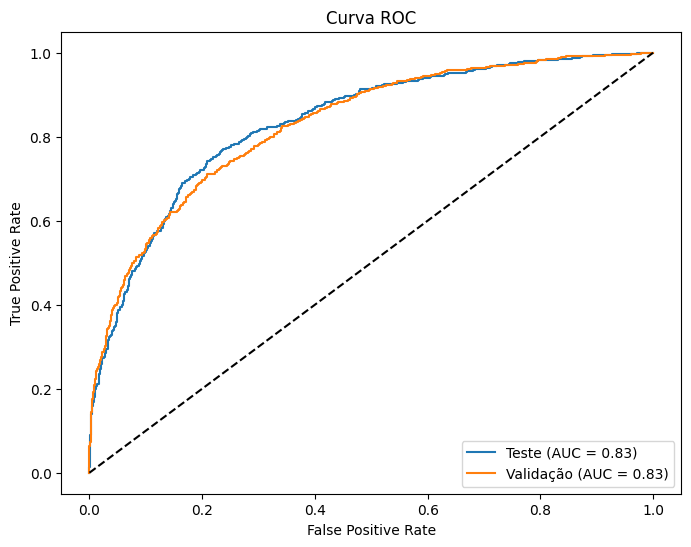

In [23]:
plot_roc_curves(y_test, y_probs_test, y_val, y_probs_val)

In [24]:
ks_test = ks_2samp(y_probs_test[y_test == 0], y_probs_test[y_test == 1]).statistic
ks_val = ks_2samp(y_probs_val[y_val == 0], y_probs_val[y_val == 1]).statistic

print(f"KS Test: {ks_test:.4f}")
print(f"KS Val: {ks_val:.4f}")

KS Test: 0.5342
KS Val: 0.5015


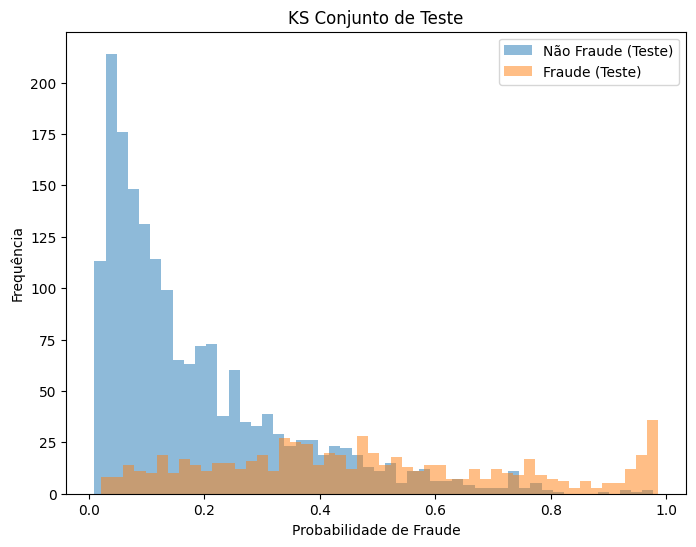

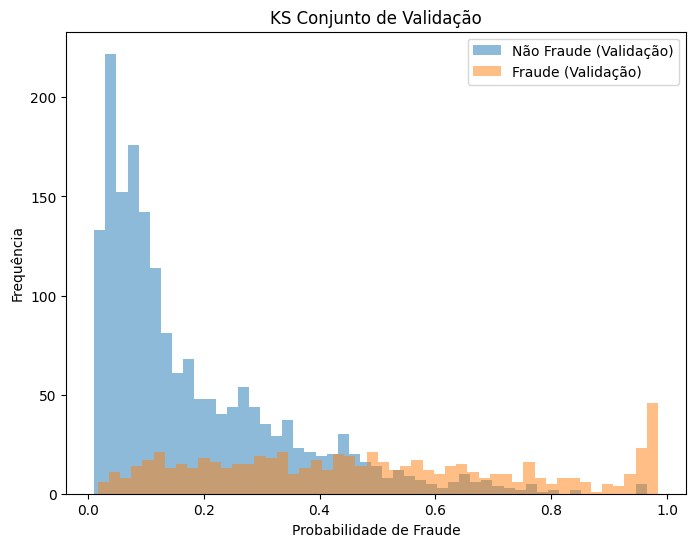

In [25]:
plt.figure(figsize=(8, 6))
plt.hist(y_probs_test[y_test == 0], bins=50, alpha=0.5, label='Não Fraude (Teste)')
plt.hist(y_probs_test[y_test == 1], bins=50, alpha=0.5, label='Fraude (Teste)')
plt.xlabel('Probabilidade de Fraude')
plt.ylabel('Frequência')
plt.title('KS Conjunto de Teste')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(y_probs_val[y_val == 0], bins=50, alpha=0.5, label='Não Fraude (Validação)')
plt.hist(y_probs_val[y_val == 1], bins=50, alpha=0.5, label='Fraude (Validação)')
plt.xlabel('Probabilidade de Fraude')
plt.ylabel('Frequência')
plt.title('KS Conjunto de Validação')
plt.legend()
plt.show()


In [26]:
ks_values = [ks_test, ks_val]
groups = ['Teste', 'Validação']

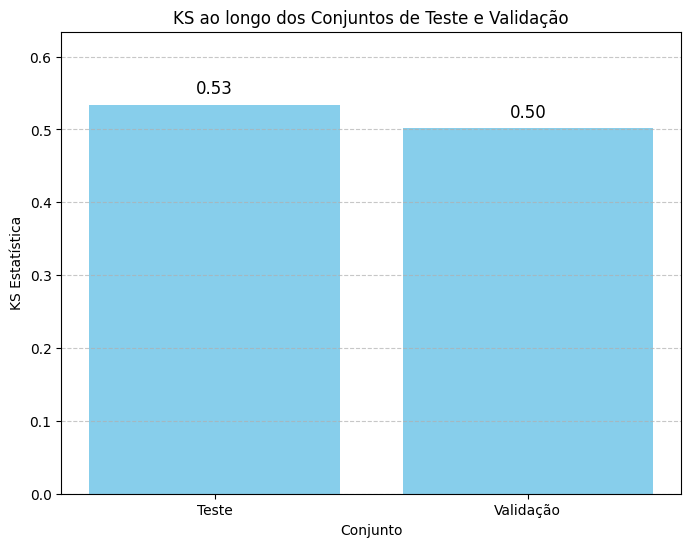

In [27]:
plt.figure(figsize=(8, 6))
bars = plt.bar(groups, ks_values, color='skyblue')
plt.xlabel("Conjunto")
plt.ylabel("KS Estatística")
plt.title("KS ao longo dos Conjuntos de Teste e Validação")
for bar, ks_val in zip(bars, ks_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{ks_val:.2f}",
             ha='center', va='bottom', fontsize=12)

plt.ylim(0, max(ks_values) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [28]:
booster = final_model.get_booster()
importance_dict = booster.get_score(importance_type='gain')

importance_df = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])
importance_df.sort_values(by='Importance', ascending=False, inplace=True)
importance_df

,Feature,Importance
4,pais_agg_ES_US_UY,87.441544
11,pais_agg_MX,21.556774
3,var_B,15.953772
15,var_Q,6.899672
0,var_S,4.558770
6,var_P,4.519962
5,var_K_100,4.302079
7,var_M,4.208065
2,var_C_log,3.902678
12,var_F_log,3.860637


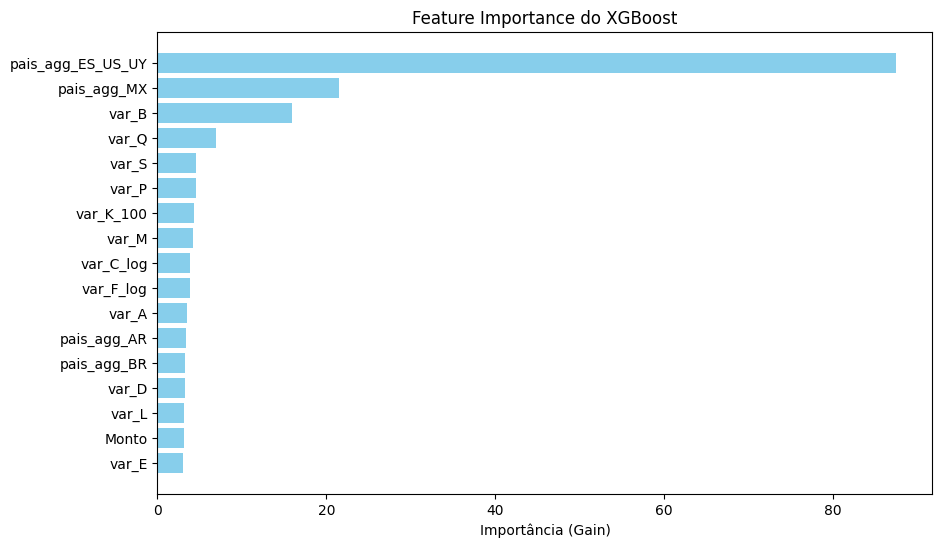

In [29]:
importance_df.sort_values(by='Importance', ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Importância (Gain)")
plt.title("Feature Importance do XGBoost")
plt.show()

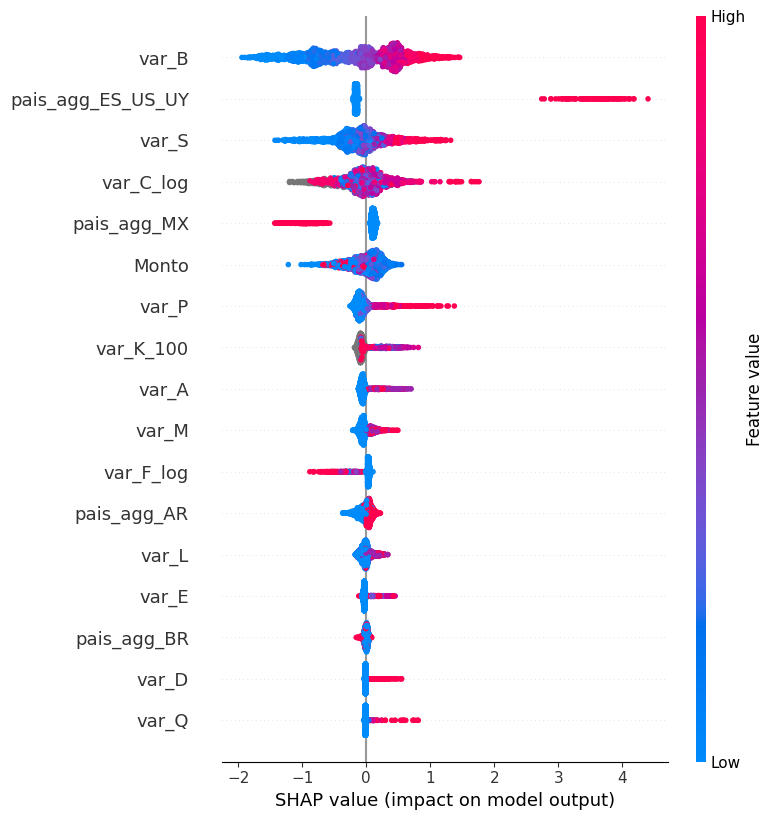

In [30]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val)

## Escolha do Threshold a partir do F1-Score

In [31]:
thresholds = np.linspace(0.01, 0.99, 100)

precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred = (y_probs_test > t).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

best_threshold_f1 = thresholds[np.argmax(f1_scores)].round(2)
print("Melhor threshold para F1-score:", best_threshold_f1)
print("F1-score correspondente:", np.max(f1_scores).round(4))

Melhor threshold para F1-score: 0.33
F1-score correspondente: 0.6459


In [32]:
for i in range(len(thresholds)):
    print(f"Threshold: {thresholds[i]:.2f}, Precision: {precisions[i]:.4f}, Recall: {recalls[i]:.4f}, F1-Score: {f1_scores[i]:.4f}")

Threshold: 0.01, Precision: 0.2743, Recall: 1.0000, F1-Score: 0.4305
Threshold: 0.02, Precision: 0.2773, Recall: 1.0000, F1-Score: 0.4342
Threshold: 0.03, Precision: 0.2880, Recall: 0.9970, F1-Score: 0.4469
Threshold: 0.04, Precision: 0.3000, Recall: 0.9896, F1-Score: 0.4604
Threshold: 0.05, Precision: 0.3145, Recall: 0.9837, F1-Score: 0.4767
Threshold: 0.06, Precision: 0.3269, Recall: 0.9763, F1-Score: 0.4898
Threshold: 0.07, Precision: 0.3389, Recall: 0.9659, F1-Score: 0.5017
Threshold: 0.08, Precision: 0.3492, Recall: 0.9556, F1-Score: 0.5115
Threshold: 0.09, Precision: 0.3625, Recall: 0.9452, F1-Score: 0.5240
Threshold: 0.10, Precision: 0.3743, Recall: 0.9378, F1-Score: 0.5351
Threshold: 0.11, Precision: 0.3888, Recall: 0.9274, F1-Score: 0.5479
Threshold: 0.12, Precision: 0.4015, Recall: 0.9215, F1-Score: 0.5594
Threshold: 0.13, Precision: 0.4130, Recall: 0.9141, F1-Score: 0.5689
Threshold: 0.14, Precision: 0.4243, Recall: 0.8963, F1-Score: 0.5759
Threshold: 0.15, Precision: 0.4342

In [33]:
# best_threshold_f1 = 0.4
best_threshold_f1

0.33

In [34]:
y_pred_test = (y_probs_test > best_threshold_f1).astype(int)
y_pred_val = (y_probs_val > best_threshold_f1).astype(int)

In [35]:
auc_test = roc_auc_score(y_test, y_probs_test)
f1_test = f1_score(y_test, y_pred_test)
auc_val = roc_auc_score(y_val, y_probs_val)
f1_val = f1_score(y_val, y_pred_val)

In [36]:
print("AUC (Teste):", auc_test)
print("F1-score (Teste):", f1_test)
print("AUC (validação):", auc_val)
print("F1-score (validação):", f1_val)

AUC (Teste): 0.8338726191216398
F1-score (Teste): 0.6467315716272601
AUC (validação): 0.8294590046402327
F1-score (validação): 0.6152758132956153


In [37]:
metrics = {
    'Métrica': ['AUC', 'F1-Score'],
    'Teste': [auc_test, f1_test],
    'Validação': [auc_val, f1_val]
}

df_metrics = pd.DataFrame(metrics)
df_metrics

,Métrica,Teste,Validação
0,AUC,0.833873,0.829459
1,F1-Score,0.646732,0.615276


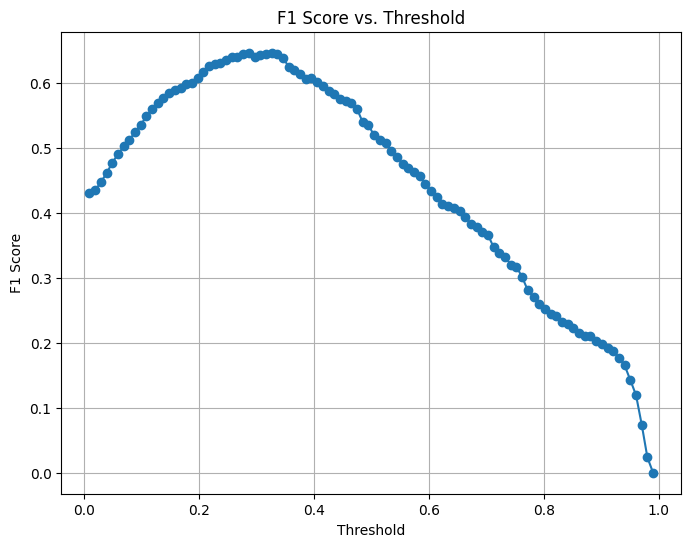

In [38]:
plt.figure(figsize=(8,6))
plt.plot(thresholds, f1_scores, marker='o')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Threshold")
plt.grid(True)
plt.show()

## Avaliação do Modelo

In [39]:
cm = confusion_matrix(y_val, y_pred_val)
tn, fp, fn, tp = cm.ravel()

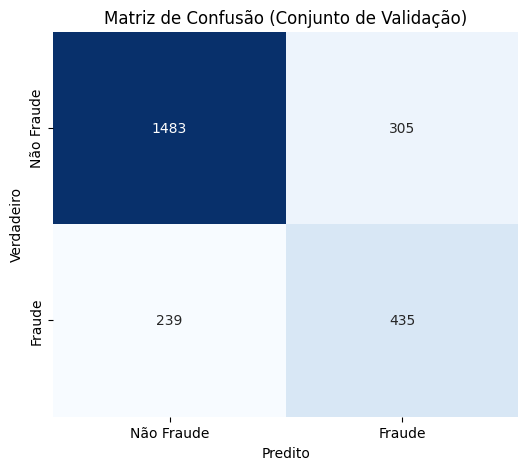

In [40]:
labels = ["Não Fraude", "Fraude"]
cm_matrix = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap="Blues", cbar=False)
plt.title('Matriz de Confusão (Conjunto de Validação)')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

In [41]:
report = classification_report(y_val, y_pred_val, target_names=["Não Fraude", "Fraude"])
print("Classification Report (Validação):\n")
print(report)

Classification Report (Validação):

              precision    recall  f1-score   support

  Não Fraude       0.86      0.83      0.85      1788
      Fraude       0.59      0.65      0.62       674

    accuracy                           0.78      2462
   macro avg       0.72      0.74      0.73      2462
weighted avg       0.79      0.78      0.78      2462



## Escolha do Threshold a partir do Lucro Máximo

In [42]:
best_threshold_f1

0.33

Melhor Threshold para Lucro: 0.18
Lucro Máximo: 38123.46


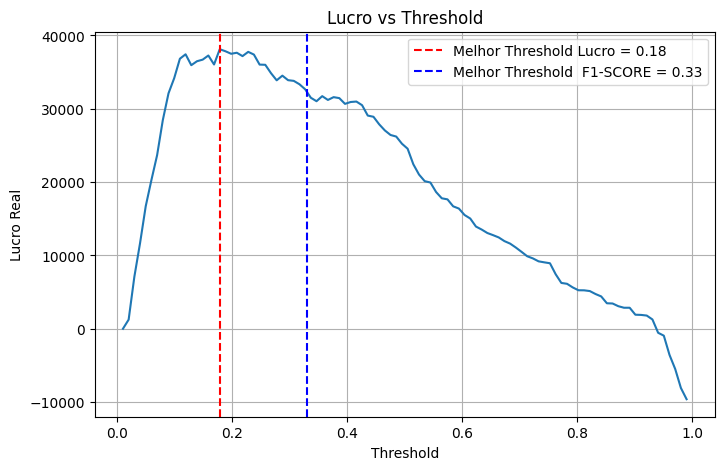

In [43]:
montos_val = X_val['Monto'].values

melhor_threshold, lucro_max = encontrar_threshold_max_lucro(y_val, y_probs_val, montos_val, best_threshold_f1)

In [44]:
calculate_profit(y_val, y_pred_val, X_val['Monto'])

Lucro: 71660.82
Prejuizo: -39994.12
Save : 50840.66
Saldo Negativo: -9561.73
Balanço Total: 72945.63
Lucro Real: 31666.70


In [58]:
50840.66/(31666.70)

1.6054928363233303

Deixamos de perder 1,6 vezes o valor que ganhamos com o Modelo proposto.

## Métricas de Fraude

In [45]:
metricas_fraude(cm, y_test, y_pred_test)

Métricas específicas de Fraude:
Detection Rate (Recall):     0.6889
Alert Rate (False Alarm):    0.3906
Hit Rate (Precision):        0.6094
Rejection Rate (Alertas):    0.3099


In [46]:
metricas_fraude(cm, y_val, y_pred_val)

Métricas específicas de Fraude:
Detection Rate (Recall):     0.6454
Alert Rate (False Alarm):    0.4122
Hit Rate (Precision):        0.5878
Rejection Rate (Alertas):    0.3006


## Avaliar por Decil

In [49]:
analisar_metricas_por_decil(y_test, y_probs_test)

,Decil,Score Mínimo,Score Máximo,Transações,Fraudes,Hit Rate,Detection Rate,Alert Rate
0,10,615,986,247,194,0.7854,0.2874,0.1003
1,9,446,615,246,142,0.5772,0.2104,0.0999
2,8,338,446,246,118,0.4797,0.1748,0.0999
3,7,248,338,246,74,0.3008,0.1096,0.0999
4,6,185,248,246,41,0.1667,0.0607,0.0999
5,5,132,185,246,47,0.1911,0.0696,0.0999
6,4,94,132,246,21,0.0854,0.0311,0.0999
7,3,64,94,246,19,0.0772,0.0281,0.0999
8,2,41,64,246,11,0.0447,0.0163,0.0999
9,1,10,41,247,8,0.0324,0.0119,0.1003


In [50]:
analisar_metricas_por_decil(y_val, y_probs_val)

,Decil,Score Mínimo,Score Máximo,Transações,Fraudes,Hit Rate,Detection Rate,Alert Rate
0,10,639,984,247,199,0.8057,0.2953,0.1003
1,9,449,638,246,145,0.5894,0.2151,0.0999
2,8,331,448,246,91,0.3699,0.1350,0.0999
3,7,251,331,246,72,0.2927,0.1068,0.0999
4,6,178,251,246,57,0.2317,0.0846,0.0999
5,5,122,177,246,47,0.1911,0.0697,0.0999
6,4,91,122,246,27,0.1098,0.0401,0.0999
7,3,65,90,246,15,0.0610,0.0223,0.0999
8,2,40,64,246,15,0.0610,0.0223,0.0999
9,1,11,40,247,6,0.0243,0.0089,0.1003


## Avaliar o público sem a variável Monto

In [51]:
X_null = base[base['Monto'].isna()][rf_fs]
y_null = base[base['Monto'].isna()]["Fraude"]

In [52]:
y_probs_null = final_model.predict_proba(X_null)[:, 1]
y_pred_null = (y_probs_null > best_threshold_f1).astype(int)

In [53]:
f1_null = f1_score(y_null, y_pred_null)
auc_null = roc_auc_score(y_null, y_probs_null)

In [54]:
print("AUC (validação):", auc_val.round(2))
print("F1-score (validação):", round(f1_val, 2))
print("AUC (Monto):", auc_null.round(2))
print("F1-score (Monto):", round(f1_null, 2))

AUC (validação): 0.83
F1-score (validação): 0.62
AUC (Monto): 0.81
F1-score (Monto): 0.57


## Salvar

In [55]:
# ! jupyter nbconvert --to html 02_Modelagem_XGBoost.ipynb